# Exploratory Data Analysis (EDA)




## Setup & Imports

In [1]:
# Add project root to path
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"✓ Project root added: {project_root}")

✓ Project root added: /home/brenda/final year project/PharmacyForecastingSystem


In [2]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import warnings

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Figure size defaults
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Packages imported successfully")

✓ Packages imported successfully


In [3]:
# Database connection
from config.database_config import DATABASE_URL

engine = create_engine(DATABASE_URL)
print("✓ Database connection established")

✓ Database connection established


## 1. DATA LOADING & OVERVIEW

In [4]:
# Load sales data with drug information
query = """
SELECT 
    sw.year,
    sw.week_number,
    sw.week_start_date,
    sw.week_end_date,
    sw.total_quantity,
    sw.avg_daily_quantity,
    d.drug_name,
    d.atc_code,
    d.drug_id
FROM raw_data.sales_weekly_raw sw
JOIN raw_data.drugs_raw d ON sw.drug_id = d.drug_id
ORDER BY sw.week_start_date, d.drug_name
"""

df = pd.read_sql_query(query, engine)

# Convert date columns to datetime
df['week_start_date'] = pd.to_datetime(df['week_start_date'])
df['week_end_date'] = pd.to_datetime(df['week_end_date'])

print(f"✓ Data loaded: {len(df):,} rows")
print(f"Date range: {df['week_start_date'].min()} to {df['week_start_date'].max()}")

✓ Data loaded: 4,972 rows
Date range: 2013-12-30 00:00:00 to 2025-12-22 00:00:00


In [5]:
# Dataset shape
print("=" * 60)
print("DATASET SHAPE")
print("=" * 60)
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

DATASET SHAPE
Rows: 4,972
Columns: 9
Memory usage: 0.77 MB


In [6]:
# Column names and data types
print("=" * 60)
print("COLUMN INFORMATION")
print("=" * 60)
print(df.dtypes)
print("\n")
df.info()

COLUMN INFORMATION
year                           int64
week_number                    int64
week_start_date       datetime64[ns]
week_end_date         datetime64[ns]
total_quantity                 int64
avg_daily_quantity           float64
drug_name                     object
atc_code                      object
drug_id                        int64
dtype: object


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4972 entries, 0 to 4971
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   year                4972 non-null   int64         
 1   week_number         4972 non-null   int64         
 2   week_start_date     4972 non-null   datetime64[ns]
 3   week_end_date       4972 non-null   datetime64[ns]
 4   total_quantity      4972 non-null   int64         
 5   avg_daily_quantity  4972 non-null   float64       
 6   drug_name           4972 non-null   object        
 7   atc_code         

In [7]:
# First and last rows
print("=" * 60)
print("FIRST 10 ROWS")
print("=" * 60)
display(df.head(10))

print("\n" + "=" * 60)
print("LAST 10 ROWS")
print("=" * 60)
display(df.tail(10))

FIRST 10 ROWS


,year,week_number,week_start_date,week_end_date,total_quantity,avg_daily_quantity,drug_name,atc_code,drug_id
0,2014,1,2013-12-30,2014-01-05,14,2.00,M01AB,M01AB,1
1,2014,1,2013-12-30,2014-01-05,11,1.67,M01AE,M01AE,2
2,2014,1,2013-12-30,2014-01-05,21,3.04,N02BA,N02BA,3
3,2014,1,2013-12-30,2014-01-05,185,26.56,N02BE,N02BE,4
4,2014,1,2013-12-30,2014-01-05,41,5.86,N05B,N05B,5
5,2014,1,2013-12-30,2014-01-05,32,4.57,R03,R03,7
6,2014,1,2013-12-30,2014-01-05,7,1.00,R06,R06,8
7,2014,2,2014-01-06,2014-01-12,29,4.19,M01AB,M01AB,1
8,2014,2,2014-01-06,2014-01-12,12,1.81,M01AE,M01AE,2
9,2014,2,2014-01-06,2014-01-12,37,5.41,N02BA,N02BA,3



LAST 10 ROWS


,year,week_number,week_start_date,week_end_date,total_quantity,avg_daily_quantity,drug_name,atc_code,drug_id
4962,2025,51,2025-12-15,2025-12-21,90,12.97,R03,R03,7
4963,2025,51,2025-12-15,2025-12-21,22,3.22,R06,R06,8
4964,2025,52,2025-12-22,2025-12-28,68,9.79,M01AB,M01AB,1
4965,2025,52,2025-12-22,2025-12-28,34,4.98,M01AE,M01AE,2
4966,2025,52,2025-12-22,2025-12-28,0,0.01,N02BA,N02BA,3
4967,2025,52,2025-12-22,2025-12-28,367,52.55,N02BE,N02BE,4
4968,2025,52,2025-12-22,2025-12-28,30,4.35,N05B,N05B,5
4969,2025,52,2025-12-22,2025-12-28,6,0.87,N05C,N05C,6
4970,2025,52,2025-12-22,2025-12-28,164,23.48,R03,R03,7
4971,2025,52,2025-12-22,2025-12-28,13,1.91,R06,R06,8


## 2. MISSING DATA ANALYSIS

In [8]:
# Missing values count
print("=" * 60)
print("MISSING VALUES ANALYSIS")
print("=" * 60)

missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum().values,
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).values
})

missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_data) > 0:
    display(missing_data)
else:
    print("✓ No missing values found!")

MISSING VALUES ANALYSIS
✓ No missing values found!


## 3. DATA QUALITY CHECKS

In [9]:
print("=" * 60)
print("DATA QUALITY CHECKS")
print("=" * 60)

# Duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates:,}")

# Duplicate key check (year, week, drug)
key_duplicates = df.duplicated(subset=['year', 'week_number', 'drug_id']).sum()
print(f"Duplicate keys (year, week, drug): {key_duplicates:,}")

# Negative values
negative_qty = (df['total_quantity'] < 0).sum()
print(f"Negative quantities: {negative_qty:,}")

# Zero values
zero_qty = (df['total_quantity'] == 0).sum()
print(f"Zero quantities: {zero_qty:,} ({zero_qty/len(df)*100:.2f}%)")

# Invalid dates (future dates)
today = pd.Timestamp.now()
future_dates = (df['week_start_date'] > today).sum()
print(f"Future dates: {future_dates:,}")

# Date consistency (week_end = week_start + 6 days)
date_diff = (df['week_end_date'] - df['week_start_date']).dt.days
invalid_weeks = (date_diff != 6).sum()
print(f"Invalid week ranges (not 7 days): {invalid_weeks:,}")

DATA QUALITY CHECKS
Duplicate rows: 0
Duplicate keys (year, week, drug): 0
Negative quantities: 0
Zero quantities: 68 (1.37%)
Future dates: 0
Invalid week ranges (not 7 days): 0


## 4. DESCRIPTIVE STATISTICS

In [10]:
# Numerical summary
print("=" * 60)
print("NUMERICAL VARIABLES SUMMARY")
print("=" * 60)
display(df.describe())

NUMERICAL VARIABLES SUMMARY


,year,week_number,week_start_date,week_end_date,total_quantity,avg_daily_quantity,drug_id
count,4972.000000,4972.000000,4972,4972,4972.000000,4972.000000,4972.000000
mean,2019.514883,26.620072,2020-01-03 12:23:44.939662336,2020-01-09 12:23:44.939662080,58.621681,8.430167,4.489139
min,2014.000000,1.000000,2013-12-30 00:00:00,2014-01-05 00:00:00,0.000000,0.010000,1.000000
25%,2017.000000,14.000000,2017-01-02 00:00:00,2017-01-08 00:00:00,18.000000,2.647500,2.000000
50%,2020.000000,27.000000,2020-01-13 00:00:00,2020-01-19 00:00:00,32.000000,4.650000,4.000000
75%,2023.000000,40.000000,2023-01-02 00:00:00,2023-01-08 00:00:00,56.000000,8.012500,7.000000
max,2025.000000,53.000000,2025-12-22 00:00:00,2025-12-28 00:00:00,546.000000,78.130000,8.000000
std,3.453280,15.066682,NaN,NaN,78.751157,11.255306,2.296228


In [11]:
# Detailed statistics for key columns
print("=" * 60)
print("QUANTITY STATISTICS")
print("=" * 60)

qty_stats = pd.DataFrame({
    'Metric': ['Mean', 'Median', 'Std Dev', 'Min', 'Max', 'Skewness', 'Kurtosis', 'Q1', 'Q3', 'IQR'],
    'total_quantity': [
        df['total_quantity'].mean(),
        df['total_quantity'].median(),
        df['total_quantity'].std(),
        df['total_quantity'].min(),
        df['total_quantity'].max(),
        df['total_quantity'].skew(),
        df['total_quantity'].kurtosis(),
        df['total_quantity'].quantile(0.25),
        df['total_quantity'].quantile(0.75),
        df['total_quantity'].quantile(0.75) - df['total_quantity'].quantile(0.25)
    ]
})

display(qty_stats)

QUANTITY STATISTICS


,Metric,total_quantity
0,Mean,58.621681
1,Median,32.000000
2,Std Dev,78.751157
3,Min,0.000000
4,Max,546.000000
5,Skewness,2.697975
6,Kurtosis,7.711899
7,Q1,18.000000
8,Q3,56.000000
9,IQR,38.000000


In [12]:
# Categorical variables summary
print("=" * 60)
print("CATEGORICAL VARIABLES SUMMARY")
print("=" * 60)

print(f"Unique drugs: {df['drug_name'].nunique()}")
print(f"Unique ATC codes: {df['atc_code'].nunique()}")
print(f"Unique years: {df['year'].nunique()}")
print(f"Date range: {df['week_start_date'].min()} to {df['week_start_date'].max()}")
print(f"Total weeks: {df[['year', 'week_number']].drop_duplicates().shape[0]}")

CATEGORICAL VARIABLES SUMMARY
Unique drugs: 8
Unique ATC codes: 8
Unique years: 12
Date range: 2013-12-30 00:00:00 to 2025-12-22 00:00:00
Total weeks: 626


## 5. UNIVARIATE ANALYSIS

### 5.1 Numerical Variables

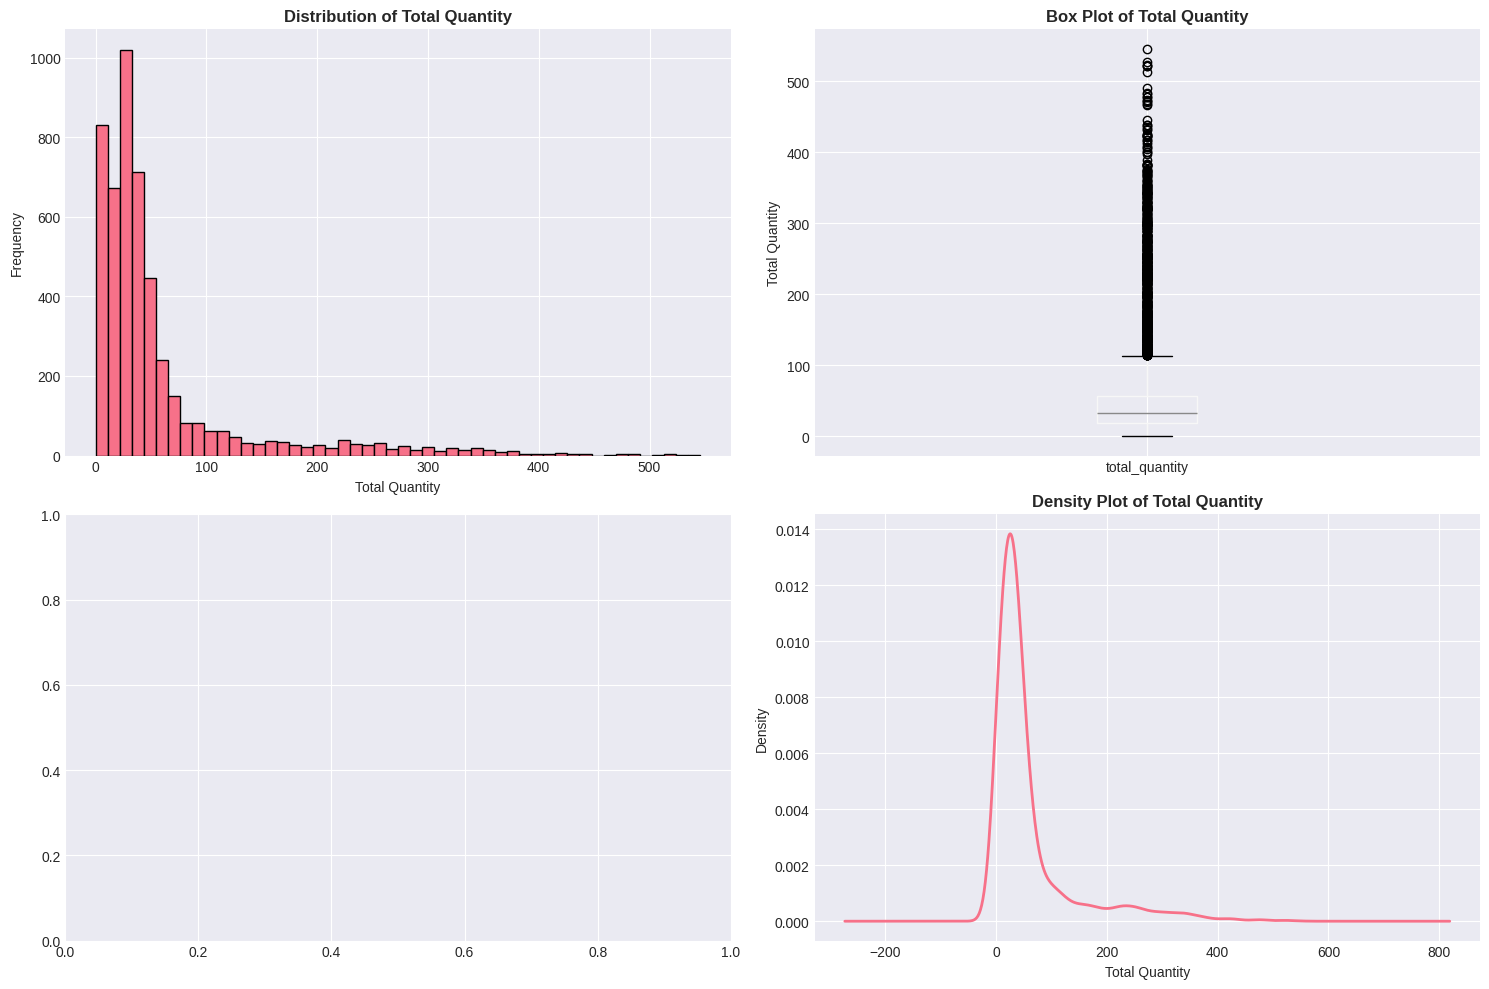

In [13]:
# Distribution plots for total_quantity
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogram
df['total_quantity'].hist(bins=50, ax=axes[0, 0], edgecolor='black')
axes[0, 0].set_title('Distribution of Total Quantity', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Total Quantity')
axes[0, 0].set_ylabel('Frequency')

# Box plot
df.boxplot(column='total_quantity', ax=axes[0, 1])
axes[0, 1].set_title('Box Plot of Total Quantity', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Total Quantity')

# Log scale histogram (if positive values)
if df['total_quantity'].min() > 0:
    df['total_quantity'].apply(np.log10).hist(bins=50, ax=axes[1, 0], edgecolor='black')
    axes[1, 0].set_title('Distribution of Total Quantity (Log Scale)', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Log10(Total Quantity)')
    axes[1, 0].set_ylabel('Frequency')

# Density plot
df['total_quantity'].plot(kind='density', ax=axes[1, 1], linewidth=2)
axes[1, 1].set_title('Density Plot of Total Quantity', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Total Quantity')

plt.tight_layout()
plt.show()

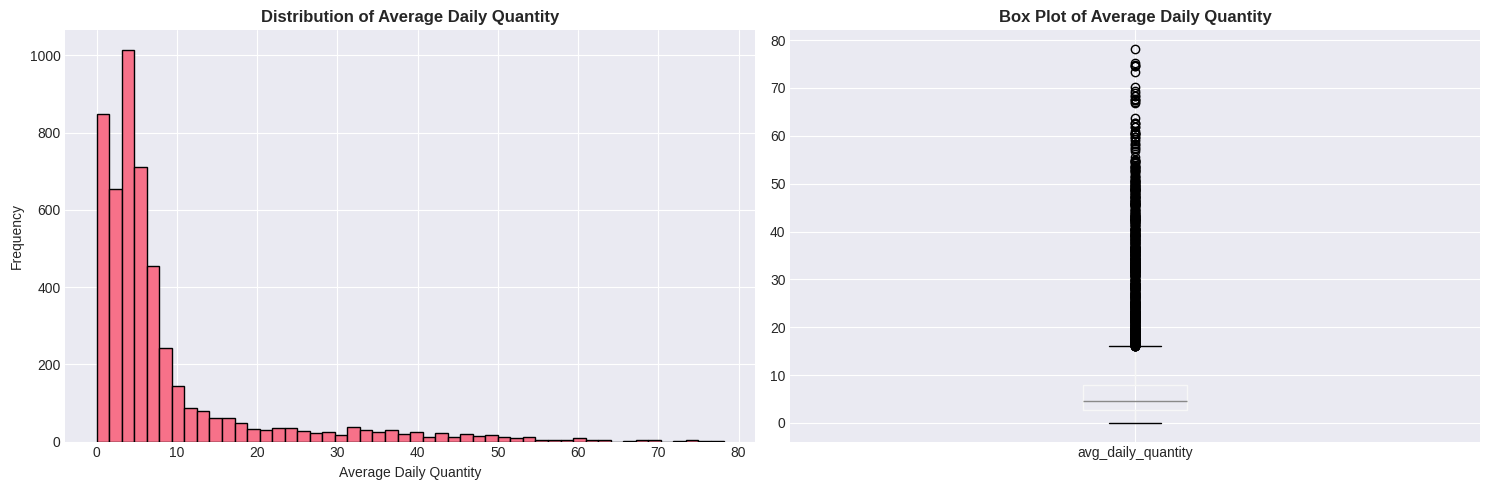

In [14]:
# Average daily quantity distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

df['avg_daily_quantity'].hist(bins=50, ax=axes[0], edgecolor='black')
axes[0].set_title('Distribution of Average Daily Quantity', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Average Daily Quantity')
axes[0].set_ylabel('Frequency')

df.boxplot(column='avg_daily_quantity', ax=axes[1])
axes[1].set_title('Box Plot of Average Daily Quantity', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### 5.2 Categorical Variables

TOP 20 DRUGS BY NUMBER OF RECORDS
drug_name
M01AB    626
M01AE    626
N02BA    626
N02BE    626
N05B     626
R03      626
R06      626
N05C     590
Name: count, dtype: int64


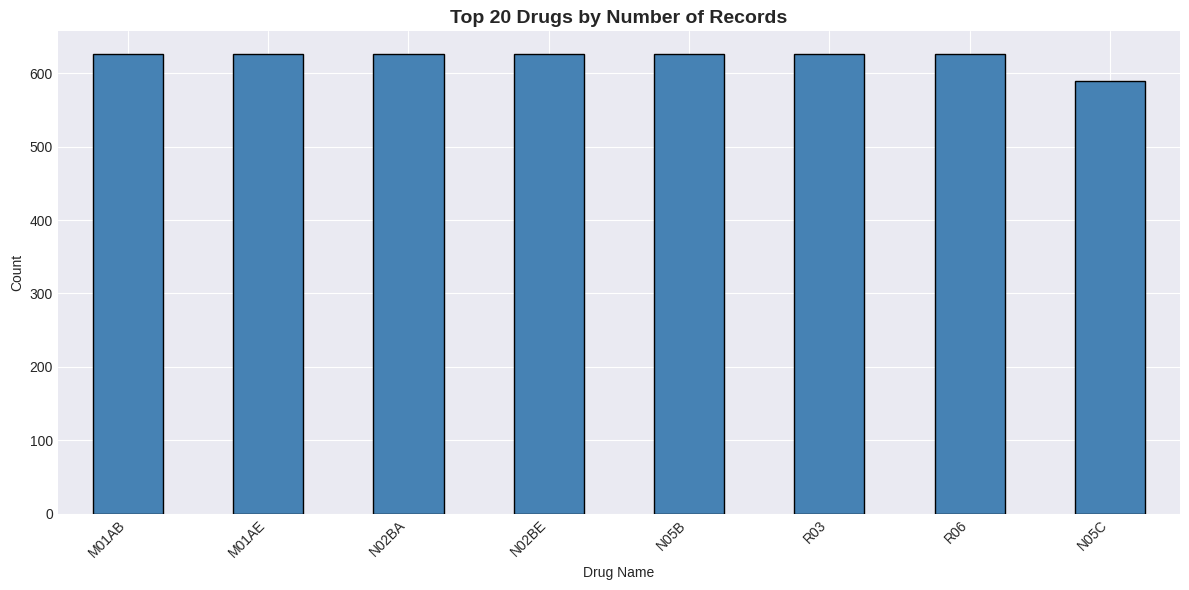

In [15]:
# Top 20 drugs by frequency
print("=" * 60)
print("TOP 20 DRUGS BY NUMBER OF RECORDS")
print("=" * 60)

top_drugs_freq = df['drug_name'].value_counts().head(20)
print(top_drugs_freq)

# Visualize
plt.figure(figsize=(12, 6))
top_drugs_freq.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 20 Drugs by Number of Records', fontsize=14, fontweight='bold')
plt.xlabel('Drug Name')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

ATC CODE DISTRIBUTION
atc_code
M01AB    626
M01AE    626
N02BA    626
N02BE    626
N05B     626
R03      626
R06      626
N05C     590
Name: count, dtype: int64


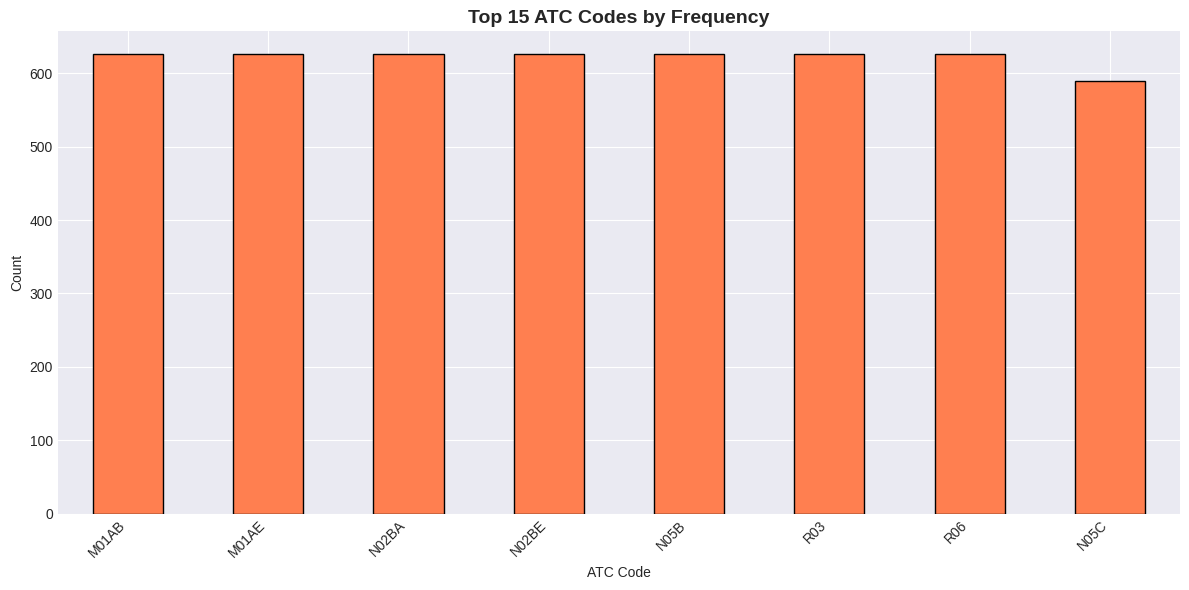

In [16]:
# ATC code distribution
print("=" * 60)
print("ATC CODE DISTRIBUTION")
print("=" * 60)

atc_counts = df['atc_code'].value_counts().head(15)
print(atc_counts)

plt.figure(figsize=(12, 6))
atc_counts.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Top 15 ATC Codes by Frequency', fontsize=14, fontweight='bold')
plt.xlabel('ATC Code')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 5.3 Temporal Variables

RECORDS PER YEAR
year
2014    414
2015    417
2016    409
2017    406
2018    407
2019    415
2020    424
2021    416
2022    416
2023    416
2024    416
2025    416
Name: count, dtype: int64


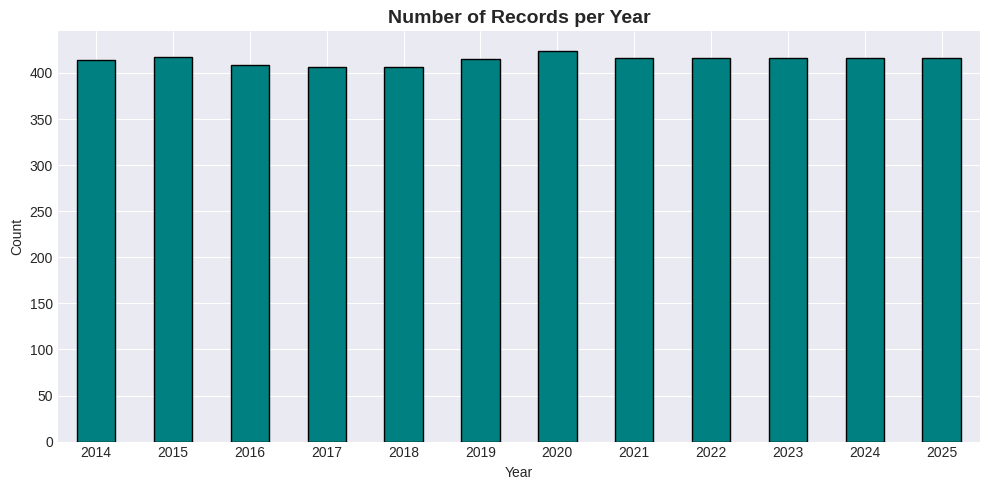

In [17]:
# Records per year
print("=" * 60)
print("RECORDS PER YEAR")
print("=" * 60)

year_counts = df['year'].value_counts().sort_index()
print(year_counts)

plt.figure(figsize=(10, 5))
year_counts.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Number of Records per Year', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [18]:
# Check for missing weeks
print("=" * 60)
print("TIME CONTINUITY CHECK")
print("=" * 60)

# Get all unique week_start_dates
all_weeks = df['week_start_date'].drop_duplicates().sort_values()
date_range = pd.date_range(start=all_weeks.min(), end=all_weeks.max(), freq='W-MON')

missing_weeks = set(date_range) - set(all_weeks)

if len(missing_weeks) > 0:
    print(f"⚠ Missing weeks detected: {len(missing_weeks)}")
    print("\nFirst 10 missing weeks:")
    for week in sorted(list(missing_weeks))[:10]:
        print(f"  - {week.date()}")
else:
    print("✓ No missing weeks detected")

TIME CONTINUITY CHECK
✓ No missing weeks detected


## 6. BIVARIATE ANALYSIS

### 6.1 Correlation Analysis

CORRELATION MATRIX


,year,week_number,total_quantity,avg_daily_quantity
year,1.000000,-0.004742,0.037551,0.038761
week_number,-0.004742,1.000000,0.000998,0.000989
total_quantity,0.037551,0.000998,1.000000,0.999992
avg_daily_quantity,0.038761,0.000989,0.999992,1.000000


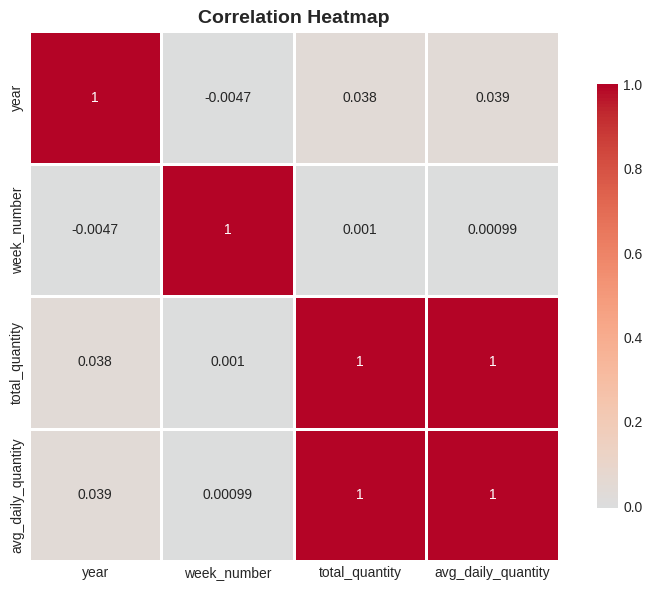

In [19]:
# Correlation matrix
numerical_cols = ['year', 'week_number', 'total_quantity', 'avg_daily_quantity']
correlation_matrix = df[numerical_cols].corr()

print("=" * 60)
print("CORRELATION MATRIX")
print("=" * 60)
display(correlation_matrix)

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.2 Sales by Drug

TOP 20 DRUGS BY TOTAL SALES
drug_name
N02BE    147433
R03       38101
N05B      33807
M01AB     24163
M01AE     17195
R06       15856
N02BA     12273
N05C       2639
Name: total_quantity, dtype: int64


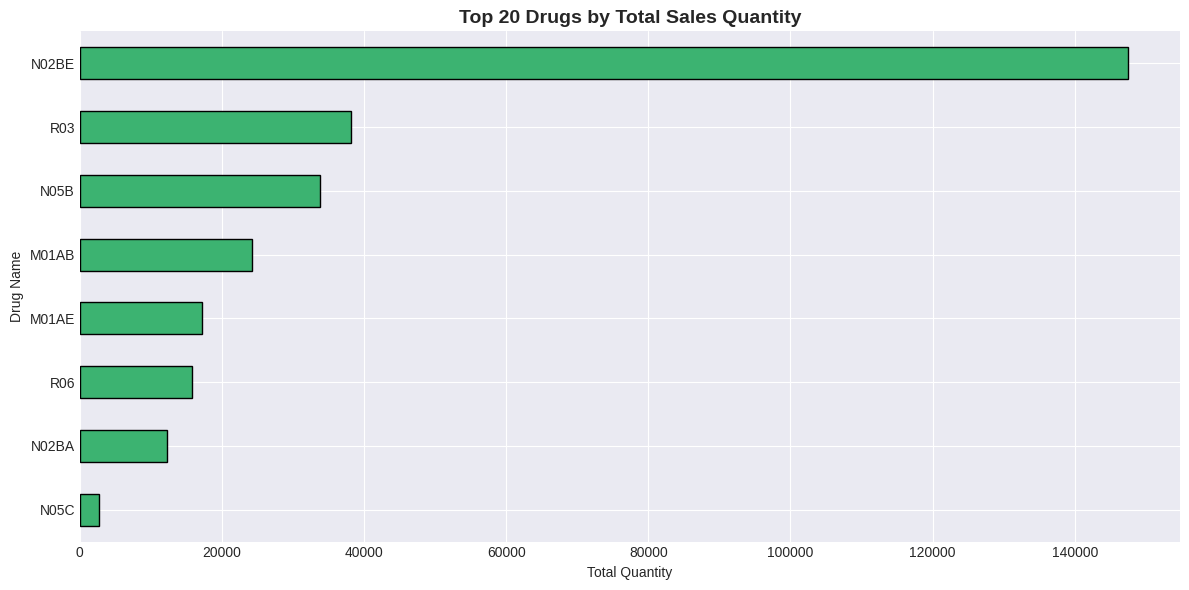

In [20]:
# Top 20 drugs by total sales
print("=" * 60)
print("TOP 20 DRUGS BY TOTAL SALES")
print("=" * 60)

top_drugs_sales = df.groupby('drug_name')['total_quantity'].sum().sort_values(ascending=False).head(20)
print(top_drugs_sales)

plt.figure(figsize=(12, 6))
top_drugs_sales.plot(kind='barh', color='mediumseagreen', edgecolor='black')
plt.title('Top 20 Drugs by Total Sales Quantity', fontsize=14, fontweight='bold')
plt.xlabel('Total Quantity')
plt.ylabel('Drug Name')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [21]:
# Drug statistics (mean, std, cv)
print("=" * 60)
print("DRUG SALES STATISTICS (Top 10)")
print("=" * 60)

drug_stats = df.groupby('drug_name')['total_quantity'].agg(['sum', 'mean', 'std', 'count'])
drug_stats['cv'] = (drug_stats['std'] / drug_stats['mean']) * 100  # Coefficient of variation
drug_stats = drug_stats.sort_values('sum', ascending=False).head(10)

display(drug_stats)

DRUG SALES STATISTICS (Top 10)


,sum,mean,std,count,cv
drug_name,,,,,
N02BE,147433,235.515974,94.539425,626,40.141407
R03,38101,60.864217,35.250452,626,57.916545
N05B,33807,54.004792,22.429872,626,41.533115
M01AB,24163,38.599042,9.940331,626,25.752792
M01AE,17195,27.468051,7.014255,626,25.536050
R06,15856,25.329073,15.174832,626,59.910728
N02BA,12273,19.605431,10.602305,626,54.078406
N05C,2639,4.472881,2.847888,590,63.670110


### 6.3 Sales by ATC Code

TOP 15 ATC CODES BY TOTAL SALES
atc_code
N02BE    147433
R03       38101
N05B      33807
M01AB     24163
M01AE     17195
R06       15856
N02BA     12273
N05C       2639
Name: total_quantity, dtype: int64


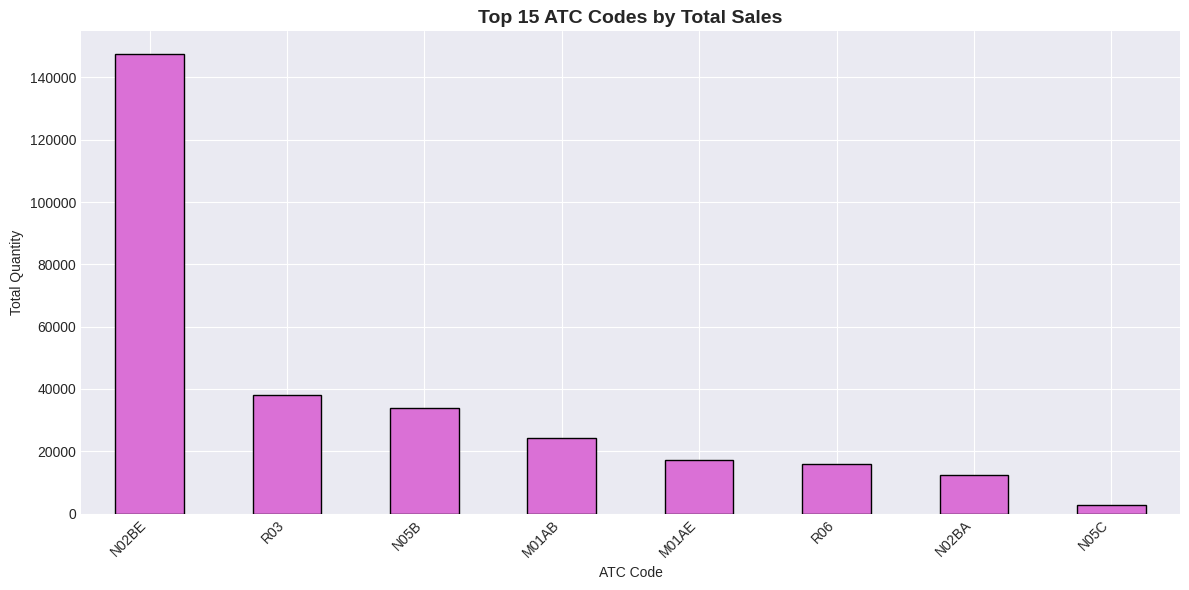

In [22]:
# Sales by ATC code
print("=" * 60)
print("TOP 15 ATC CODES BY TOTAL SALES")
print("=" * 60)

atc_sales = df.groupby('atc_code')['total_quantity'].sum().sort_values(ascending=False).head(15)
print(atc_sales)

plt.figure(figsize=(12, 6))
atc_sales.plot(kind='bar', color='orchid', edgecolor='black')
plt.title('Top 15 ATC Codes by Total Sales', fontsize=14, fontweight='bold')
plt.xlabel('ATC Code')
plt.ylabel('Total Quantity')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 6.4 Time Series Analysis

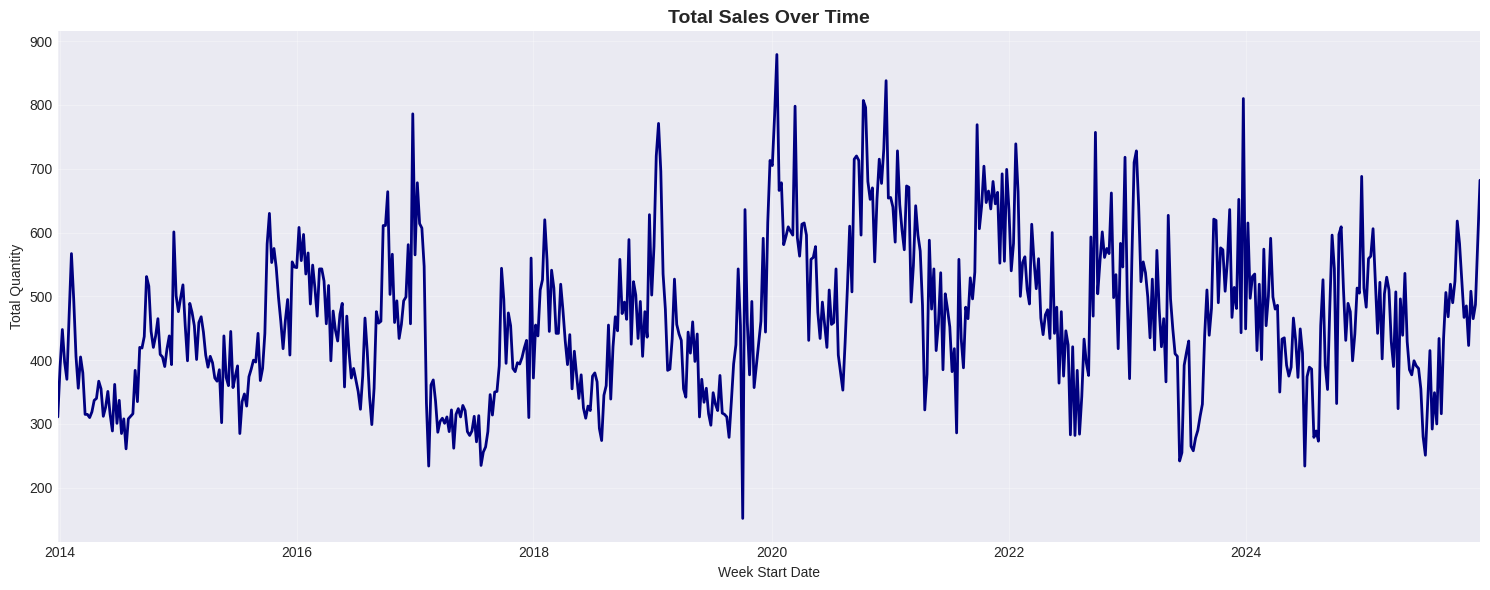

In [23]:
# Total sales over time
weekly_sales = df.groupby('week_start_date')['total_quantity'].sum().sort_index()

plt.figure(figsize=(15, 6))
weekly_sales.plot(linewidth=2, color='navy')
plt.title('Total Sales Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Week Start Date')
plt.ylabel('Total Quantity')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

TOTAL SALES BY YEAR
year
2014    19901
2015    23018
2016    25027
2017    19224
2018    22685
2019    22331
2020    31923
2021    28781
2022    26258
2023    24967
2024    23613
2025    23739
Name: total_quantity, dtype: int64


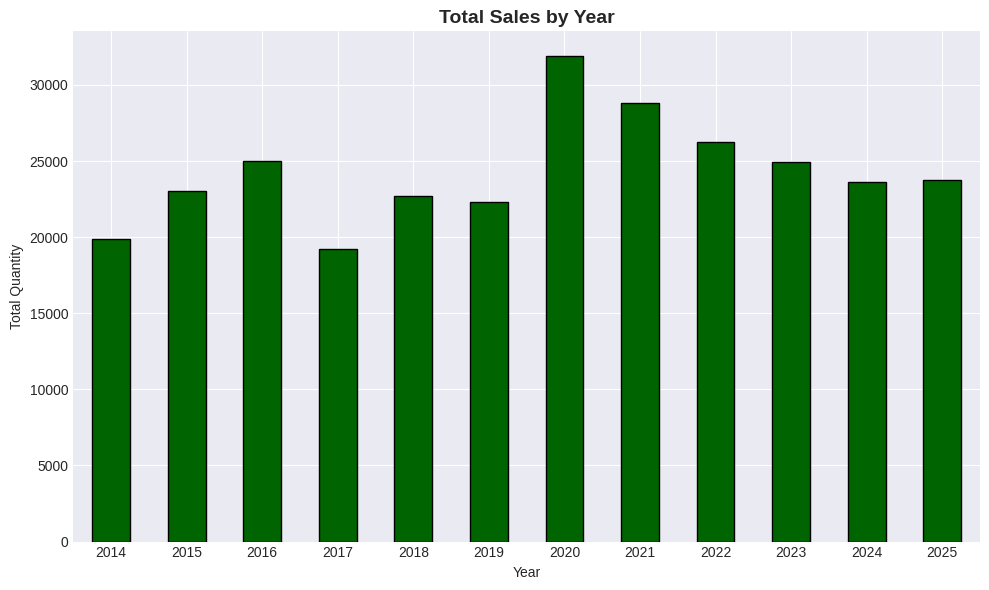

In [24]:
# Sales by year
yearly_sales = df.groupby('year')['total_quantity'].sum().sort_index()

print("=" * 60)
print("TOTAL SALES BY YEAR")
print("=" * 60)
print(yearly_sales)

plt.figure(figsize=(10, 6))
yearly_sales.plot(kind='bar', color='darkgreen', edgecolor='black')
plt.title('Total Sales by Year', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Total Quantity')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

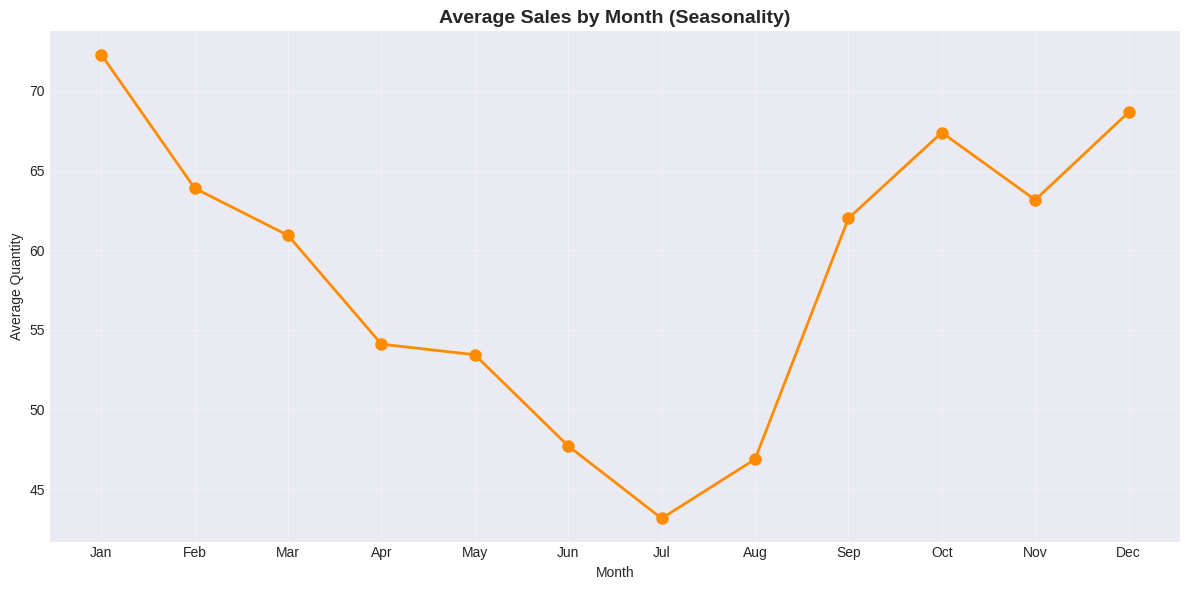

In [25]:
# Average sales by week number (seasonality check)
df['month'] = df['week_start_date'].dt.month
monthly_avg = df.groupby('month')['total_quantity'].mean().sort_index()

plt.figure(figsize=(12, 6))
monthly_avg.plot(kind='line', marker='o', linewidth=2, markersize=8, color='darkorange')
plt.title('Average Sales by Month (Seasonality)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Quantity')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                           'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. MULTIVARIATE ANALYSIS

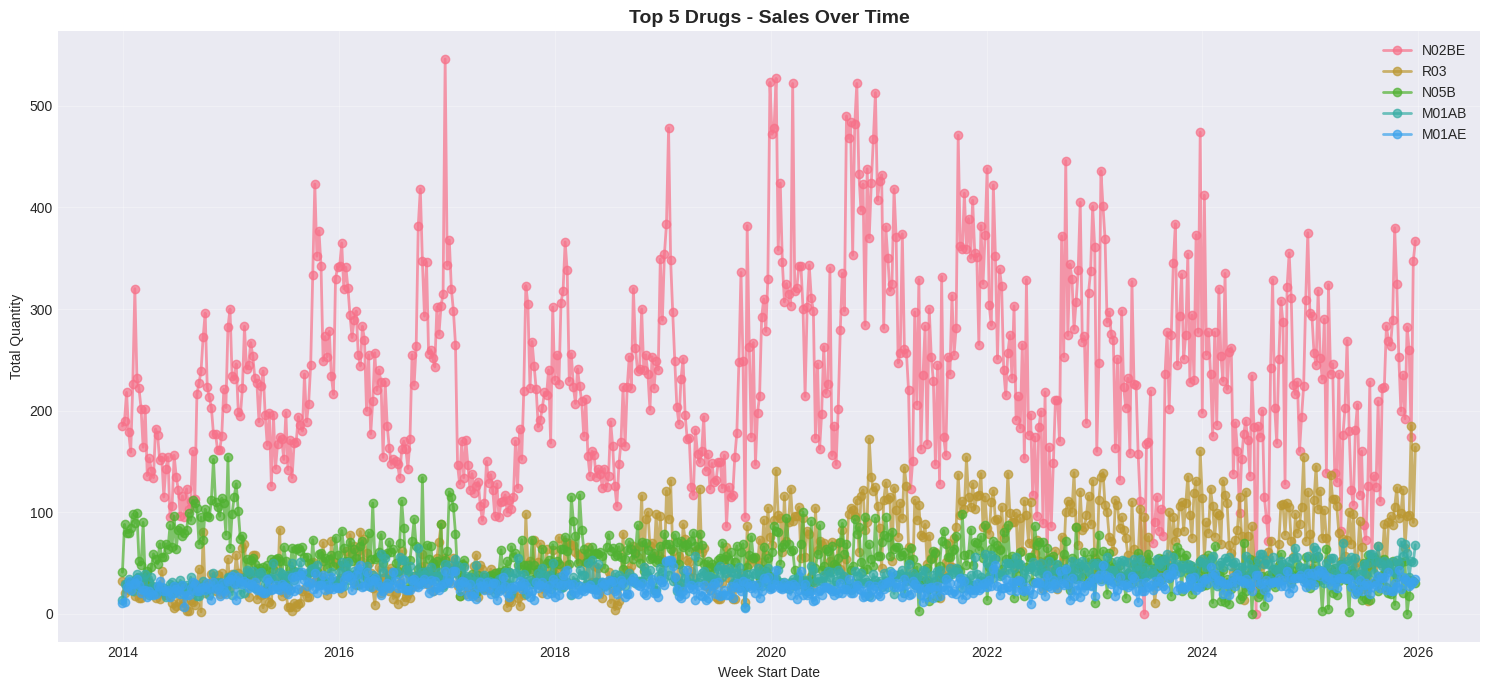

In [26]:
# Top 5 drugs over time
top_5_drugs = df.groupby('drug_name')['total_quantity'].sum().nlargest(5).index

plt.figure(figsize=(15, 7))
for drug in top_5_drugs:
    drug_data = df[df['drug_name'] == drug].groupby('week_start_date')['total_quantity'].sum()
    plt.plot(drug_data.index, drug_data.values, marker='o', linewidth=2, label=drug, alpha=0.7)

plt.title('Top 5 Drugs - Sales Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Week Start Date')
plt.ylabel('Total Quantity')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

PIVOT TABLE: YEAR vs TOP 10 DRUGS


drug_name,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
year,,,,,,,,
2014,1413,1219,1585,9115,4277,268,1238,786
2015,1894,1492,1597,12138,3001,164,1748,984
2016,2077,1559,1630,13231,3142,207,2133,1048
2017,1815,1360,1265,9207,2543,176,1884,974
2018,1753,1359,1096,11160,3256,235,2649,1177
2019,1916,1369,1071,10863,2973,227,2677,1235
2020,1744,1272,1235,18372,3177,230,4455,1438
2021,1869,1308,879,15334,3008,237,4533,1613
2022,2257,1449,676,13186,2641,242,4257,1550


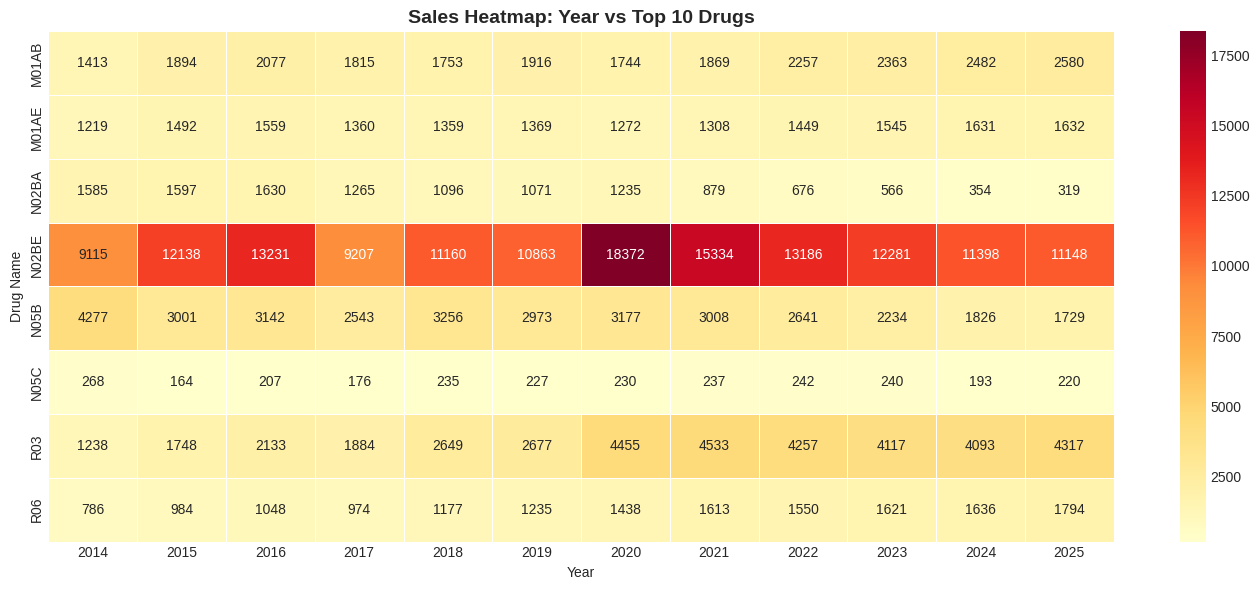

In [27]:
# Pivot table: Year vs Top 10 Drugs
top_10_drugs = df.groupby('drug_name')['total_quantity'].sum().nlargest(10).index
pivot_data = df[df['drug_name'].isin(top_10_drugs)].pivot_table(
    values='total_quantity',
    index='year',
    columns='drug_name',
    aggfunc='sum',
    fill_value=0
)

print("=" * 60)
print("PIVOT TABLE: YEAR vs TOP 10 DRUGS")
print("=" * 60)
display(pivot_data)

# Heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(pivot_data.T, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Sales Heatmap: Year vs Top 10 Drugs', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Drug Name')
plt.tight_layout()
plt.show()

## 8. OUTLIER DETECTION

In [28]:
# IQR method for outlier detection
print("=" * 60)
print("OUTLIER DETECTION (IQR METHOD)")
print("=" * 60)

Q1 = df['total_quantity'].quantile(0.25)
Q3 = df['total_quantity'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['total_quantity'] < lower_bound) | (df['total_quantity'] > upper_bound)]

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower Bound: {lower_bound:.2f}")
print(f"Upper Bound: {upper_bound:.2f}")
print(f"\nOutliers detected: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)")

if len(outliers) > 0:
    print("\nTop 10 outliers:")
    display(outliers.nlargest(10, 'total_quantity')[['drug_name', 'week_start_date', 'total_quantity']])

OUTLIER DETECTION (IQR METHOD)
Q1: 18.00
Q3: 56.00
IQR: 38.00
Lower Bound: -39.00
Upper Bound: 113.00

Outliers detected: 647 (13.01%)

Top 10 outliers:


,drug_name,week_start_date,total_quantity
1235,N02BE,2016-12-26,546
2495,N02BE,2020-01-20,527
2471,N02BE,2019-12-30,523
2559,N02BE,2020-03-16,522
2807,N02BE,2020-10-19,522
2879,N02BE,2020-12-21,513
2767,N02BE,2020-09-14,490
2783,N02BE,2020-09-28,484
2799,N02BE,2020-10-12,482
2080,N02BE,2019-01-21,478


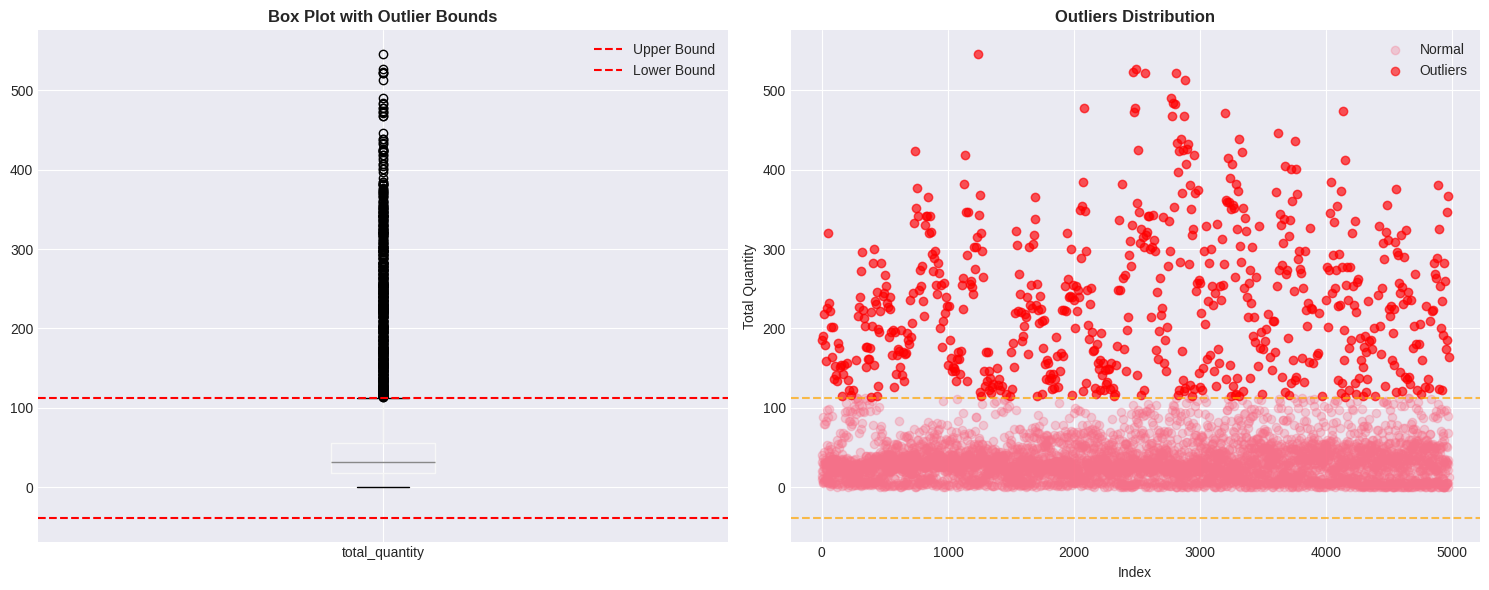

In [29]:
# Visualize outliers
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Box plot with outliers highlighted
df.boxplot(column='total_quantity', ax=axes[0])
axes[0].axhline(y=upper_bound, color='r', linestyle='--', label='Upper Bound')
axes[0].axhline(y=lower_bound, color='r', linestyle='--', label='Lower Bound')
axes[0].set_title('Box Plot with Outlier Bounds', fontsize=12, fontweight='bold')
axes[0].legend()

# Scatter plot of outliers
axes[1].scatter(df.index, df['total_quantity'], alpha=0.3, label='Normal')
axes[1].scatter(outliers.index, outliers['total_quantity'], color='red', alpha=0.6, label='Outliers')
axes[1].axhline(y=upper_bound, color='orange', linestyle='--', alpha=0.7)
axes[1].axhline(y=lower_bound, color='orange', linestyle='--', alpha=0.7)
axes[1].set_title('Outliers Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Index')
axes[1].set_ylabel('Total Quantity')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. BUSINESS INSIGHTS

MARKET CONCENTRATION ANALYSIS
Top 3 drugs account for 80% of total sales
That's 37.5% of all drugs


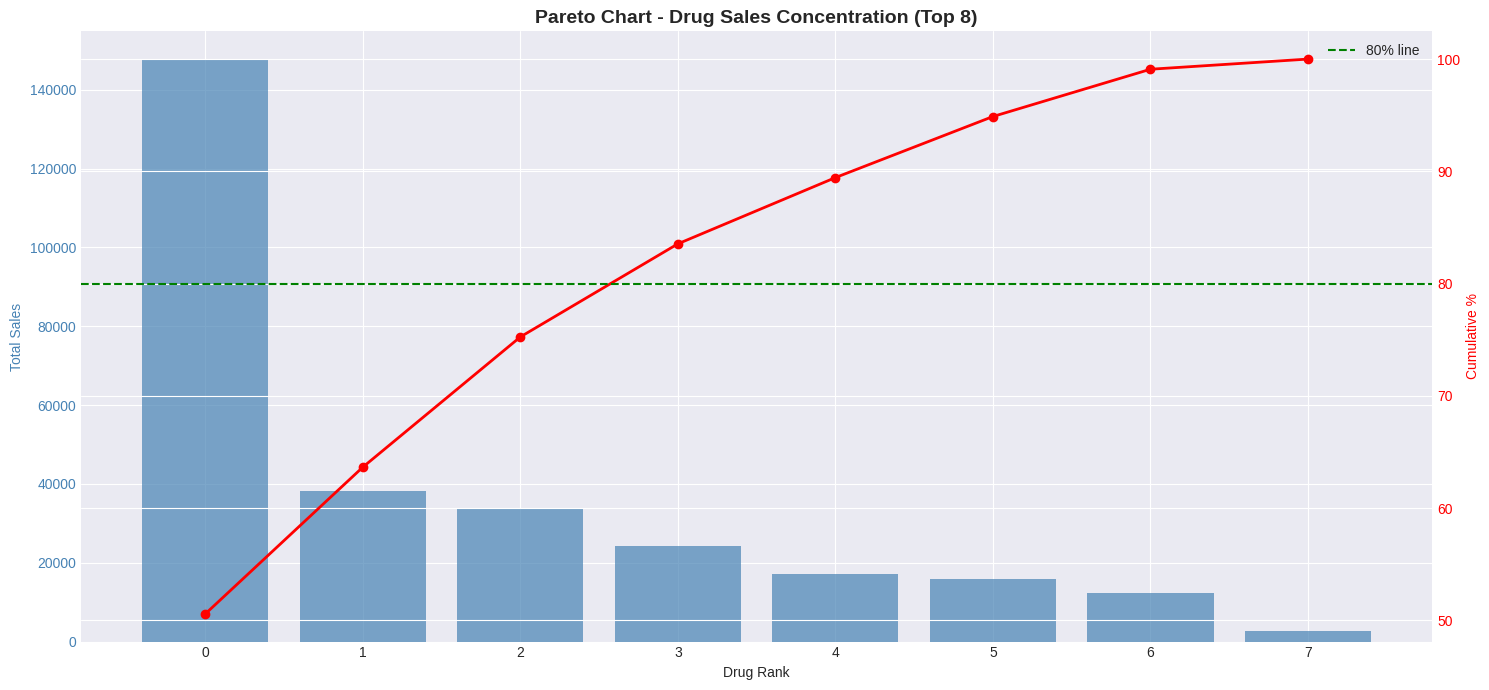

In [30]:
# Market concentration (Pareto principle)
print("=" * 60)
print("MARKET CONCENTRATION ANALYSIS")
print("=" * 60)

drug_sales = df.groupby('drug_name')['total_quantity'].sum().sort_values(ascending=False)
total_sales = drug_sales.sum()
cumulative_sales = drug_sales.cumsum()
cumulative_pct = (cumulative_sales / total_sales) * 100

# How many drugs account for 80% of sales?
drugs_80_pct = (cumulative_pct <= 80).sum()
print(f"Top {drugs_80_pct} drugs account for 80% of total sales")
print(f"That's {drugs_80_pct/len(drug_sales)*100:.1f}% of all drugs")

# Pareto chart
fig, ax1 = plt.subplots(figsize=(15, 7))

top_n = min(30, len(drug_sales))  # Use available drugs if less than 30
ax1.bar(range(top_n), drug_sales.head(top_n).values, color='steelblue', alpha=0.7)
ax1.set_xlabel('Drug Rank')
ax1.set_ylabel('Total Sales', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(range(top_n), cumulative_pct.head(top_n).values, color='red', marker='o', linewidth=2)
ax2.axhline(y=80, color='green', linestyle='--', label='80% line')
ax2.set_ylabel('Cumulative %', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.legend()

plt.title(f'Pareto Chart - Drug Sales Concentration (Top {top_n})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

MOST VOLATILE DRUGS (Top 10 by Coefficient of Variation)


,mean,std,count,cv
drug_name,,,,
N05C,4.472881,2.847888,590,63.670110
R06,25.329073,15.174832,626,59.910728
R03,60.864217,35.250452,626,57.916545
N02BA,19.605431,10.602305,626,54.078406
N05B,54.004792,22.429872,626,41.533115
N02BE,235.515974,94.539425,626,40.141407
M01AB,38.599042,9.940331,626,25.752792
M01AE,27.468051,7.014255,626,25.536050


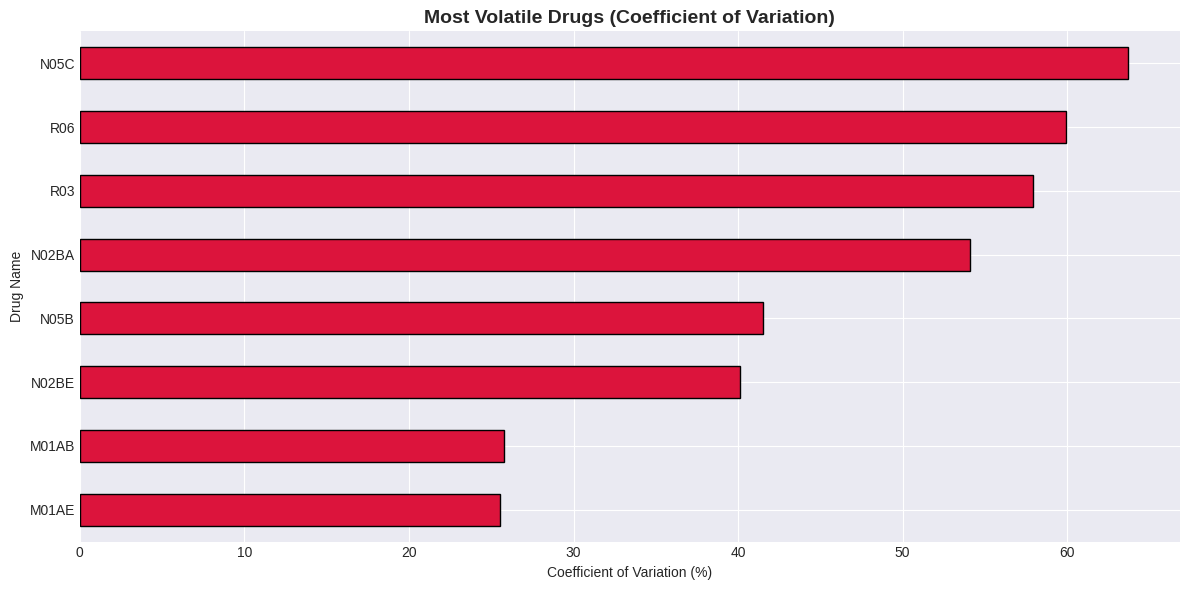

In [31]:
# Sales volatility (drugs with highest variation)
print("=" * 60)
print("MOST VOLATILE DRUGS (Top 10 by Coefficient of Variation)")
print("=" * 60)

volatility = df.groupby('drug_name')['total_quantity'].agg(['mean', 'std', 'count'])
volatility = volatility[volatility['count'] >= 10]  # At least 10 records
volatility['cv'] = (volatility['std'] / volatility['mean']) * 100
volatility = volatility.sort_values('cv', ascending=False).head(10)

display(volatility)

plt.figure(figsize=(12, 6))
volatility['cv'].plot(kind='barh', color='crimson', edgecolor='black')
plt.title('Most Volatile Drugs (Coefficient of Variation)', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient of Variation (%)')
plt.ylabel('Drug Name')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

YEAR-OVER-YEAR GROWTH RATE


,Year,Total Sales,YoY Growth (%)
0,2014,19901,NaN
1,2015,23018,15.662530
2,2016,25027,8.727952
3,2017,19224,-23.186958
4,2018,22685,18.003537
5,2019,22331,-1.560503
6,2020,31923,42.953741
7,2021,28781,-9.842433
8,2022,26258,-8.766200
9,2023,24967,-4.916597


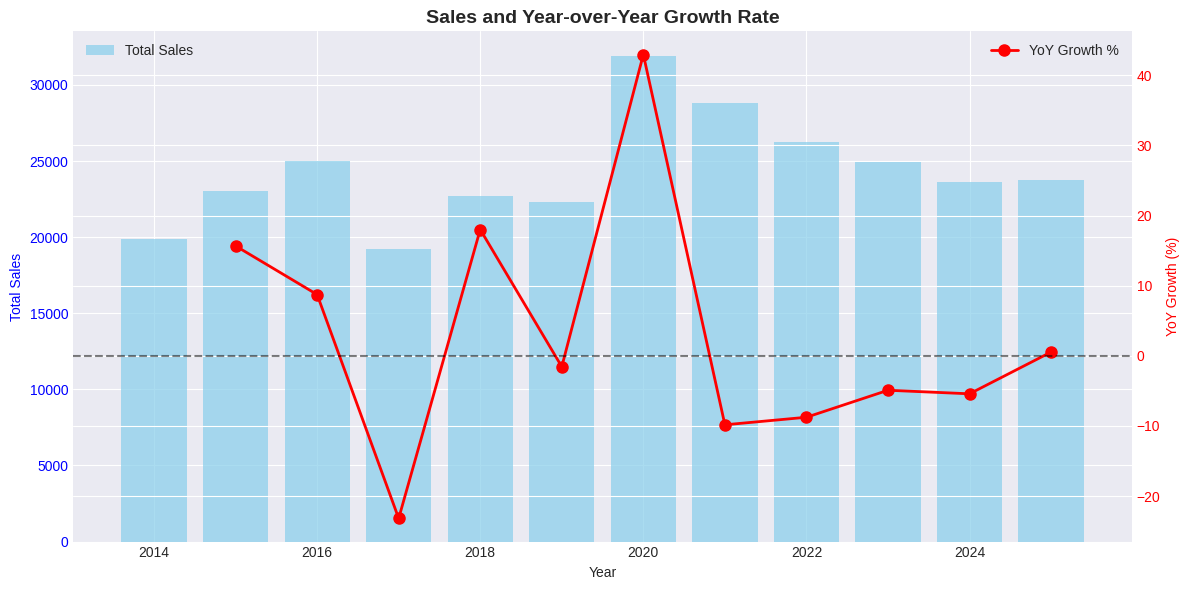

In [32]:
# Growth rate analysis (Year-over-Year)
if df['year'].nunique() > 1:
    print("=" * 60)
    print("YEAR-OVER-YEAR GROWTH RATE")
    print("=" * 60)
    
    yearly_total = df.groupby('year')['total_quantity'].sum().sort_index()
    growth_rate = yearly_total.pct_change() * 100
    
    growth_df = pd.DataFrame({
        'Year': yearly_total.index,
        'Total Sales': yearly_total.values,
        'YoY Growth (%)': growth_rate.values
    })
    
    display(growth_df)
    
    # Visualize
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    ax1.bar(growth_df['Year'], growth_df['Total Sales'], color='skyblue', alpha=0.7, label='Total Sales')
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Total Sales', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.legend(loc='upper left')
    
    ax2 = ax1.twinx()
    ax2.plot(growth_df['Year'], growth_df['YoY Growth (%)'], color='red', marker='o', 
             linewidth=2, markersize=8, label='YoY Growth %')
    ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax2.set_ylabel('YoY Growth (%)', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.legend(loc='upper right')
    
    plt.title('Sales and Year-over-Year Growth Rate', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 10. KEY FINDINGS SUMMARY

In [33]:
print("=" * 60)
print("KEY FINDINGS SUMMARY")
print("=" * 60)

print("\n📊 DATASET OVERVIEW:")
print(f"  • Total records: {len(df):,}")
print(f"  • Unique drugs: {df['drug_name'].nunique()}")
print(f"  • Unique ATC codes: {df['atc_code'].nunique()}")
print(f"  • Date range: {df['week_start_date'].min().date()} to {df['week_start_date'].max().date()}")
print(f"  • Total sales volume: {df['total_quantity'].sum():,.0f}")

print("\n📈 SALES STATISTICS:")
print(f"  • Average weekly sales per drug: {df['total_quantity'].mean():,.2f}")
print(f"  • Median weekly sales per drug: {df['total_quantity'].median():,.2f}")
print(f"  • Standard deviation: {df['total_quantity'].std():,.2f}")
print(f"  • Min sales: {df['total_quantity'].min():,.0f}")
print(f"  • Max sales: {df['total_quantity'].max():,.0f}")

print("\n🏆 TOP PERFORMERS:")
top_3 = df.groupby('drug_name')['total_quantity'].sum().nlargest(3)
for i, (drug, sales) in enumerate(top_3.items(), 1):
    print(f"  {i}. {drug}: {sales:,.0f}")

print("\n⚠️ DATA QUALITY:")
print(f"  • Missing values: {df.isnull().sum().sum()}")
print(f"  • Duplicate rows: {df.duplicated().sum()}")
print(f"  • Zero quantities: {(df['total_quantity'] == 0).sum()}")
print(f"  • Outliers (IQR method): {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)")

print("\n💡 INSIGHTS:")
print(f"  • Market concentration: Top {drugs_80_pct} drugs account for 80% of sales")
print(f"  • Distribution skewness: {df['total_quantity'].skew():.2f} {'(right-skewed)' if df['total_quantity'].skew() > 0 else '(left-skewed)'}")

if df['year'].nunique() > 1:
    latest_year = df['year'].max()
    previous_year = latest_year - 1
    if previous_year in df['year'].values:
        latest_sales = df[df['year'] == latest_year]['total_quantity'].sum()
        previous_sales = df[df['year'] == previous_year]['total_quantity'].sum()
        growth = ((latest_sales - previous_sales) / previous_sales) * 100
        print(f"  • YoY growth ({previous_year} to {latest_year}): {growth:+.2f}%")

print("\n" + "=" * 60)

KEY FINDINGS SUMMARY

📊 DATASET OVERVIEW:
  • Total records: 4,972
  • Unique drugs: 8
  • Unique ATC codes: 8
  • Date range: 2013-12-30 to 2025-12-22
  • Total sales volume: 291,467

📈 SALES STATISTICS:
  • Average weekly sales per drug: 58.62
  • Median weekly sales per drug: 32.00
  • Standard deviation: 78.75
  • Min sales: 0
  • Max sales: 546

🏆 TOP PERFORMERS:
  1. N02BE: 147,433
  2. R03: 38,101
  3. N05B: 33,807

⚠️ DATA QUALITY:
  • Missing values: 0
  • Duplicate rows: 0
  • Zero quantities: 68
  • Outliers (IQR method): 647 (13.01%)

💡 INSIGHTS:
  • Market concentration: Top 3 drugs account for 80% of sales
  • Distribution skewness: 2.70 (right-skewed)
  • YoY growth (2024 to 2025): +0.53%

